<a href="https://colab.research.google.com/github/Shashi-kumar-g/machine-learning-26/blob/main/Day05_miniproject_069_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

df = pd.read_csv("/content/day05_hospital_readmission_raw - day05_hospital_readmission_raw.csv")
print(df.shape)
df.head()

(3822, 19)


,record_id,patient_id,admission_date,age,sex,zip_code,insurance,num_prior_admissions,primary_diagnosis,length_of_stay,num_medications,bmi,creatinine,hba1c,discharge_disposition,followup_scheduled,readmitted_30d,days_to_next_admission,total_episode_cost_usd
0,R002547,P01164,2021-10-18,55,F,388001.0,Private,0,Other,1,8,27.0,2.01,NaN,Home,Y,1,9.0,26118
1,R000370,P00170,2021-03-06,22,M,388004.0,Uninsured,0,COPD,7,8,22.2,0.74,6.2,Home health,Y,0,NaN,15635
2,R002873,P01310,2023-06-06,72,F,388001.0,Private,2,Other,2,5,28.1,0.69,5.7,Skilled nursing,Y,0,NaN,7453
3,R000693,P00312,2021-08-09,56,F,388006.0,Uninsured,0,Hip fracture,11,8,26.1,0.96,6.6,Home,Y,0,NaN,10593
4,R000006,P00003,2022-07-04,41,F,388003.0,Private,1,Other,2,10,22.7,0.79,7.5,Home,N,0,NaN,10011


In [3]:
# Prepare target and dates
df["y"] = df["readmitted_30d"].astype(str).str.strip().str.lower().map(
    {"1": 1, "0": 0, "yes": 1, "no": 0}
)
df["date"] = pd.to_datetime(df["admission_date"], format="mixed", errors="coerce")

print("Unknown target labels:", df["y"].isna().sum())
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Positive rate:", round(df["y"].mean(), 3))
print("Always predict no accuracy:", round((df["y"] == 0).mean(), 3))

Unknown target labels: 0
Date range: 2021-01-01 00:00:00 to 2024-11-02 00:00:00
Positive rate: 0.158
Always predict no accuracy: 0.842


In [4]:
# Duplicate checks
print("Exact duplicates:", df.duplicated().sum())
print("Duplicates ignoring record_id:", df.drop(columns=["record_id"]).duplicated().sum())
print("Same patient and admission date:", df.duplicated(["patient_id", "admission_date"]).sum())

near = df[df.duplicated(["patient_id", "admission_date"], keep=False)]
display(near[["patient_id", "admission_date", "record_id", "readmitted_30d"]].head(20))

Exact duplicates: 60
Duplicates ignoring record_id: 72
Same patient and admission date: 101


,patient_id,admission_date,record_id,readmitted_30d
17,P01595,2022-10-07,R900007,1
78,P01599,2021-10-03,R003492,0
142,P00814,2022-02-08,R001826,0
145,P00874,2024-04-07,R900017,0
150,P01326,2024-03-05,R002914,0
153,P00052,2023-09-06,R000099,0
163,P00654,2023-05-25,R001453,0
178,P01682,2023-06-12,R003681,0
181,P00592,2022-12-30,R001329,0
203,P01674,2022-05-04,R003662,0


In [5]:
# Missing values
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
}).sort_values("missing_percent", ascending=False)
display(missing)

# Missing lab values by year and diagnosis
df["year"] = df["date"].dt.year
display(df.groupby("year")[["creatinine", "hba1c"]].agg(lambda x: x.isna().mean()).round(2))
display(df.groupby("primary_diagnosis")[["creatinine", "hba1c"]].agg(lambda x: x.isna().mean()).round(2))

,missing_count,missing_percent
days_to_next_admission,3306,86.50
hba1c,1097,28.70
creatinine,526,13.76
bmi,238,6.23
zip_code,101,2.64
sex,0,0.00
age,0,0.00
admission_date,0,0.00
patient_id,0,0.00
record_id,0,0.00


,creatinine,hba1c
year,,
2021,0.00,0.29
2022,0.00,0.28
2023,0.25,0.29
2024,0.45,0.29


,creatinine,hba1c
primary_diagnosis,,
COPD,0.13,0.35
Diabetes,0.14,0.04
Heart failure,0.13,0.34
Hip fracture,0.13,0.37
Other,0.14,0.36
Pneumonia,0.15,0.35


In [6]:
# Check unusual values
for col in ["age", "length_of_stay", "bmi", "num_medications",
            "num_prior_admissions", "creatinine", "hba1c"]:
    print(col, "min =", df[col].min(), "max =", df[col].max())

for col in ["sex", "insurance", "primary_diagnosis",
            "discharge_disposition", "followup_scheduled", "readmitted_30d"]:
    print("\\n", col)
    print(df[col].value_counts(dropna=False))

age min = -5 max = 230
length_of_stay min = -2 max = 365
bmi min = 0.0 max = 999.0
num_medications min = 0 max = 21
num_prior_admissions min = 0 max = 4
creatinine min = 0.4 max = 4.42
hba1c min = 4.0 max = 12.4
\n sex
sex
F         1855
M         1759
Male       108
female     100
Name: count, dtype: int64
\n insurance
insurance
Government    1631
Private       1625
Uninsured      566
Name: count, dtype: int64
\n primary_diagnosis
primary_diagnosis
Diabetes         802
Heart failure    738
COPD             670
Pneumonia        641
Other            603
Hip fracture     368
Name: count, dtype: int64
\n discharge_disposition
discharge_disposition
Home               1964
Home health         738
Skilled nursing     592
Rehab               360
home                 91
home health          33
skilled nursing      26
rehab                18
Name: count, dtype: int64
\n followup_scheduled
followup_scheduled
Y    2661
N    1161
Name: count, dtype: int64
\n readmitted_30d
readmitted_30d
0      31

Future admission field:


y,0,1
days_to_next_admission,,
False,0.968,0.032
True,0.033,0.967


Cost by target:


,count,median,mean
y,,,
0,3217,9456.0,10028.61
1,605,19123.0,20314.48


,rows,readmission_rate,creatinine_missing,hba1c_missing
year,,,,
2021,1091,0.134,0.000,0.289
2022,1050,0.145,0.000,0.284
2023,1142,0.183,0.248,0.289
2024,539,0.182,0.451,0.286


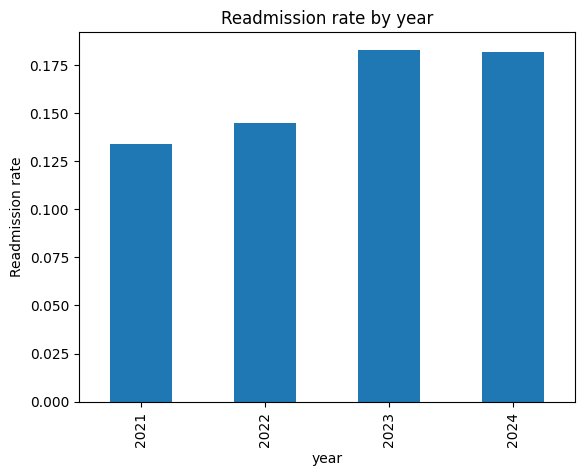

In [7]:
# Check possible leakage
print("Future admission field:")
display(pd.crosstab(df["days_to_next_admission"].notna(), df["y"], normalize="index").round(3))

print("Cost by target:")
display(df.groupby("y")["total_episode_cost_usd"].agg(["count", "median", "mean"]).round(2))

# Readmission rate over time
display(df.groupby("year").agg(
    rows=("y", "size"),
    readmission_rate=("y", "mean"),
    creatinine_missing=("creatinine", lambda x: x.isna().mean()),
    hba1c_missing=("hba1c", lambda x: x.isna().mean())
).round(3))

df.groupby("year")["y"].mean().plot(kind="bar", title="Readmission rate by year")
plt.ylabel("Readmission rate")
plt.show()

In [8]:
# Basic cleaning for model comparison
data = df.dropna(subset=["y", "date"]).copy()

data.loc[(data["age"] < 0) | (data["age"] > 120), "age"] = np.nan
data.loc[data["length_of_stay"] < 0, "length_of_stay"] = np.nan
data.loc[(data["bmi"] < 10) | (data["bmi"] > 80), "bmi"] = np.nan

data = data.drop_duplicates().copy()
data["year"] = data["date"].dt.year
data["month"] = data["date"].dt.month

# Do not use identifiers or the target as features
excluded = ["record_id", "patient_id", "admission_date", "date",
            "readmitted_30d", "y"]
all_features = [c for c in data.columns if c not in excluded]

# These fields may contain information unavailable at prediction time
leaky_features = ["days_to_next_admission", "total_episode_cost_usd"]
clean_features = [c for c in all_features if c not in leaky_features]

train_random, test_random = train_test_split(
    data.index, test_size=0.2, random_state=42, stratify=data["y"]
)
train_time = data.index[data["date"] < "2023-07-01"]
test_time = data.index[data["date"] >= "2023-07-01"]

print("Rows after basic cleaning:", len(data))
print("Random test rows:", len(test_random))
print("Time test rows:", len(test_time))

Rows after basic cleaning: 3762
Random test rows: 753
Time test rows: 1121


In [9]:
def run_model(train_ids, test_ids, features, setup_name):
    train = data.loc[train_ids]
    test = data.loc[test_ids]

    X_train = train[features]
    X_test = test[features]
    y_train = train["y"].astype(int)
    y_test = test["y"].astype(int)

    cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = [c for c in features if c not in cat_cols]

    numeric_pipe = Pipeline([
        ("fill", SimpleImputer(strategy="median"))
    ])
    category_pipe = Pipeline([
        ("fill", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(handle_unknown="ignore"))
    ])

    prep = ColumnTransformer([
        ("numbers", numeric_pipe, num_cols),
        ("categories", category_pipe, cat_cols)
    ])

    model = Pipeline([
        ("prep", prep),
        ("classifier", HistGradientBoostingClassifier(max_iter=100, random_state=42))
    ])

    model.fit(X_train, y_train)
    scores = model.predict_proba(X_test)[:, 1]

    return {
        "Setup": setup_name,
        "ROC-AUC": round(roc_auc_score(y_test, scores), 3),
        "Average precision": round(average_precision_score(y_test, scores), 3),
        "Test positive rate": round(y_test.mean(), 3),
        "Train rows": len(train),
        "Test rows": len(test)
    }

results = pd.DataFrame([
    run_model(train_random, test_random, all_features, "All columns - random split"),
    run_model(train_time, test_time, all_features, "All columns - time split"),
    run_model(train_random, test_random, clean_features, "Leakage fields removed - random split"),
    run_model(train_time, test_time, clean_features, "Leakage fields removed - time split")
])

display(results)

,Setup,ROC-AUC,Average precision,Test positive rate,Train rows,Test rows
0,All columns - random split,0.901,0.838,0.158,3009,753
1,All columns - time split,0.923,0.883,0.191,2641,1121
2,Leakage fields removed - random split,0.602,0.248,0.158,3009,753
3,Leakage fields removed - time split,0.621,0.292,0.191,2641,1121


In [10]:
# Save results for use in the report
results.to_csv("/content/day05_model_results.csv", index=False)
print("Saved results to day05_model_results.csv")

Saved results to day05_model_results.csv
